In [15]:
# TITANIC DATA CLEANING PROJECT
# STEP 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [16]:

# STEP 2: LOAD THE DATASET

df = pd.read_csv("C:/Users/User/Desktop/PROJECTS/Data Cleaning Challenge/data/Titanic-Dataset.csv")


In [17]:

# STEP 3: UNDERSTAND THE DATA
# Display first 5 rows
print("FIRST 5 ROWS OF DATASET")
print(df.head())

# Information about dataset
print("\nDATASET INFO")
print(df.info())

# Statistical summary
print("\nSTATISTICAL SUMMARY")
print(df.describe())

# Column names
print("\nCOLUMN NAMES")
print(df.columns)


FIRST 5 ROWS OF DATASET
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.

In [18]:

# DATA CLEANING STARTS HERE
# STEP 4: CHECK MISSING VALUES
print("\nMISSING VALUES")
print(df.isnull().sum())


MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [19]:

# STEP 5: HANDLE MISSING VALUES
#AGE COLUMN
df['Age'] = df['Age'].fillna(df['Age'].median())
#EMBARKED COLUMN
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#CABIN COLUMN 
df.drop('Cabin', axis=1, inplace=True)

In [20]:

# STEP 6: CHECK DUPLICATES
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())
# Remove duplicates if present
df.drop_duplicates(inplace=True)


DUPLICATE ROWS
0


In [21]:

# STEP 7: CHECK DATA TYPES
print("\nDATA TYPES")
print(df.dtypes)


DATA TYPES
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [22]:

# STEP 8: CLEAN CATEGORICAL DATA
print("\nUNIQUE VALUES IN SEX COLUMN")
print(df['Sex'].unique())
df['Sex'] = df['Sex'].str.lower()


UNIQUE VALUES IN SEX COLUMN
['male' 'female']


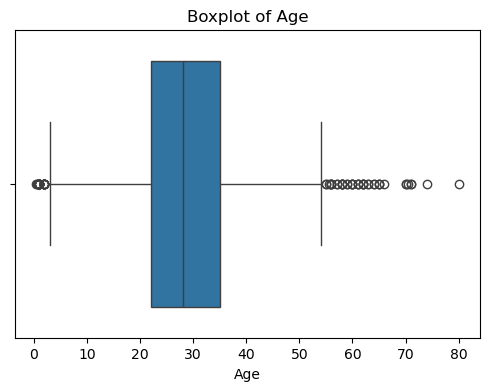

In [23]:

# STEP 9: HANDLE OUTLIERS
# Boxplot helps detect outliers

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()
# Remove unrealistic ages above 80
df = df[df['Age'] <= 80]

In [24]:
print(df['Sex'].unique())
print(df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q']


In [25]:
# STEP 10: DROP IRRELEVANT COLUMNS
# Name and Ticket are not very useful
# for basic ML analysis

df.drop(['Name', 'Ticket'], axis=1, inplace=True)




In [26]:
# STEP 11: STANDARDIZE COLUMN NAMES
# Convert column names to lowercase
# Replace spaces with underscore

df.columns = df.columns.str.lower().str.replace(" ", "_")

print("\nUPDATED COLUMN NAMES")
print(df.columns)





UPDATED COLUMN NAMES
Index(['passengerid', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
       'fare', 'embarked'],
      dtype='object')


In [28]:
# STEP 12: ENCODE CATEGORICAL VARIABLES
# Machine learning models work better with numbers
# Male -> 0
# Female -> 1

df['sex'] = df['sex'].astype(str).str.strip().str.lower()

df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})
# Encode embarked column

df['embarked'] = df['embarked'].astype(str).str.strip().str.upper()

df['embarked'] = df['embarked'].map({
    'C': 0,
    'Q': 1,
    'S': 2
})



FINAL MISSING VALUES CHECK
passengerid    0
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
dtype: int64

FINAL DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    int64  
 4   age          891 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB
None

FINAL FIRST 5 ROWS
   passengerid  survived  pclass  sex   age  sibsp  parch     fare  embarked
0            1         0       3    0  22.0      1      0   7.2500 

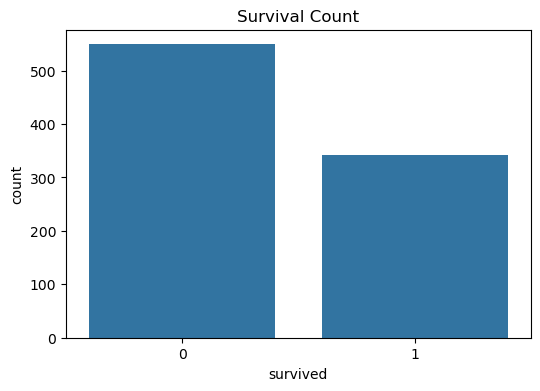

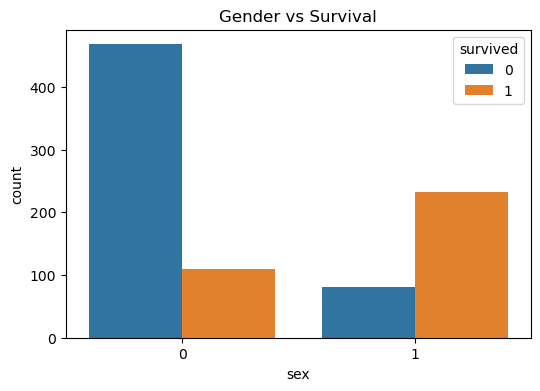

In [29]:
# STEP 13: FINAL VALIDATION
print("\nFINAL MISSING VALUES CHECK")
print(df.isnull().sum())

print("\nFINAL DATASET INFO")
print(df.info())

print("\nFINAL FIRST 5 ROWS")
print(df.head())


plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()


# Gender vs Survival

plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Gender vs Survival")
plt.show()




In [30]:
# STEP 14: SAVE CLEANED DATASET
df.to_csv("cleaned_titanic.csv", index=False)
print("\nCLEANED DATASET SAVED SUCCESSFULLY")
# PROJECT COMPLETE
print("\nDATA CLEANING PROJECT COMPLETED SUCCESSFULLY!")


CLEANED DATASET SAVED SUCCESSFULLY

DATA CLEANING PROJECT COMPLETED SUCCESSFULLY!


In [31]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\User\Desktop\PROJECTS\Data Cleaning Challenge\code
['cleaned_titanic.csv', 'data_cleaning.ipynb']
